In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor  # Тема 9-й недели
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [45]:
# ПРЯМАЯ ССЫЛКА. Убедитесь, что внутри кавычек только адрес, начинающийся на https
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(url)

# Проверка загрузки
print("Данные успешно загружены!")
display(df.head())

Данные успешно загружены!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Проверка на пропуски (Missing Values):
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


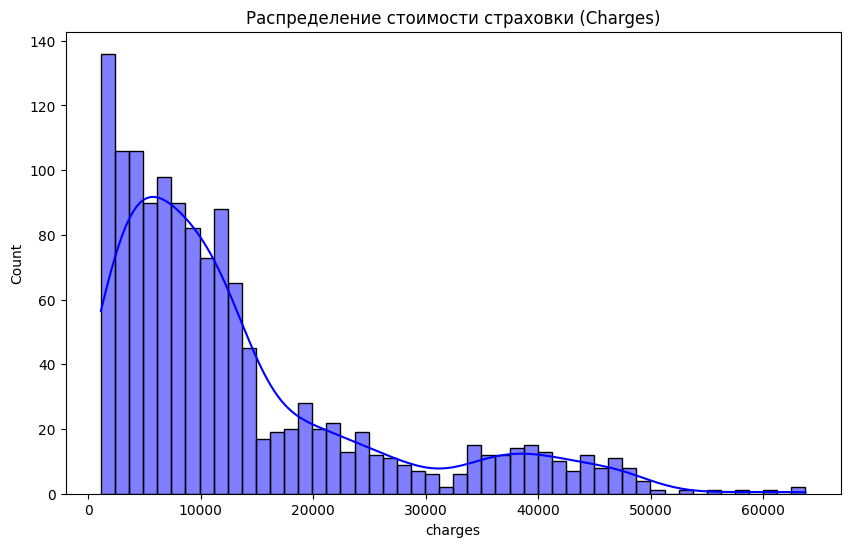

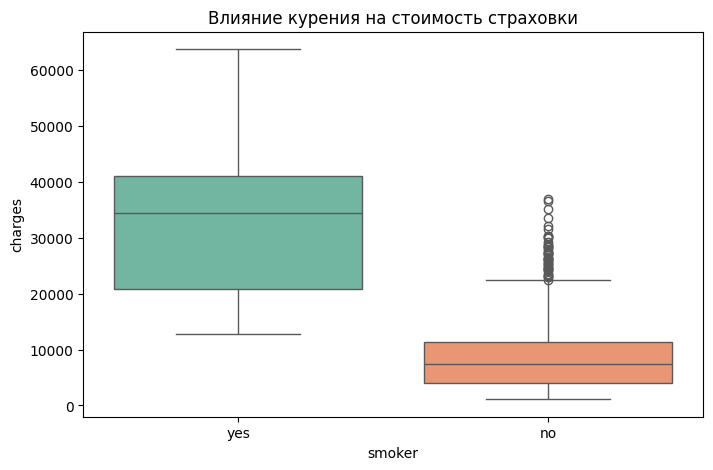

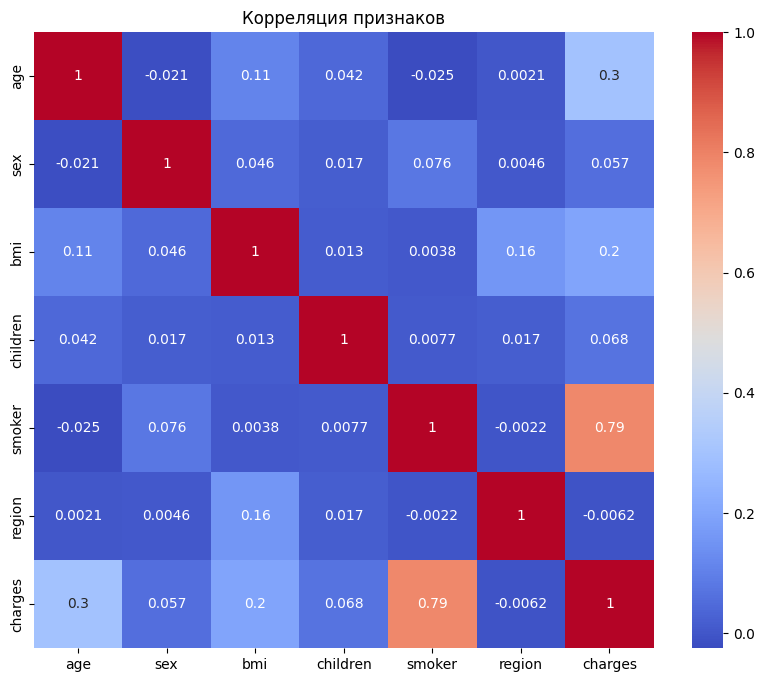

In [46]:
# Проверка на наличие пустых значений
print("Проверка на пропуски (Missing Values):")
print(df.isnull().sum())
print("\nИнформация о данных:")
print(df.info())

# График 1: Распределение стоимости страховки
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], bins=50, kde=True, color='blue')
plt.title('Распределение стоимости страховки (Charges)')
plt.show()

# График 2: Влияние курения на стоимость (Boxplot - Неделя 7)
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Влияние курения на стоимость страховки')
plt.show()

# График 3: Матрица корреляции (Heatmap - Неделя 7)
plt.figure(figsize=(10, 8))
# Кодируем временно для корреляции
temp_df = df.copy()
for col in ['sex', 'smoker', 'region']:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col])
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

In [47]:
df_processed = df.copy()

# 1. Encoding (Неделя 7)
le = LabelEncoder()
df_processed['sex'] = le.fit_transform(df_processed['sex'])
df_processed['smoker'] = le.fit_transform(df_processed['smoker'])

# One-hot encoding для 'region'
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

# Разделение на признаки (X) и целевую переменную (y)
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

# Разделение на выборки (Неделя 8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scaling (Неделя 5/7)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Данные готовы к обучению.")

Данные готовы к обучению.


In [48]:
# Модель 1: Линейная Регрессия (Тема недели 8)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# Модель 2: K-Ближайших Соседей (KNN) (Тема недели 9)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)


,Model,R2 Score,MAE,MSE
0,Linear Regression,0.783593,4181.194474,3.359692e+07
1,KNN Regressor,0.803800,3494.746058,3.045987e+07


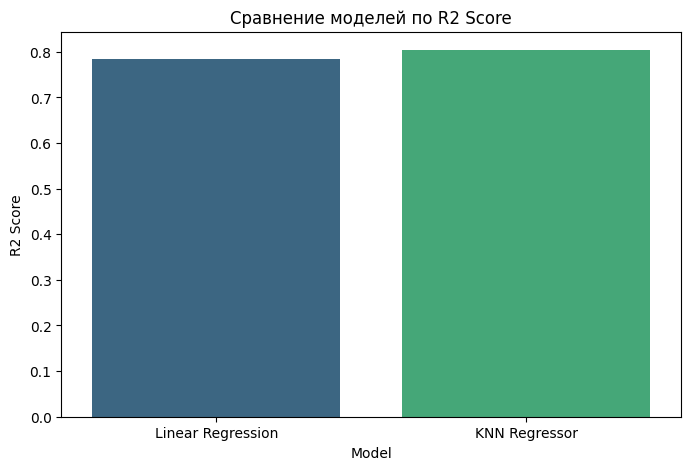

In [49]:
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return [name, r2, mae, mse]

results = [
    evaluate(y_test, lr_predictions, 'Linear Regression'),
    evaluate(y_test, knn_predictions, 'KNN Regressor')
]

results_df = pd.DataFrame(results, columns=['Model', 'R2 Score', 'MAE', 'MSE'])
display(results_df)

# Визуализация сравнения
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('Сравнение моделей по R2 Score')
plt.show()
